In [12]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from skimage.registration import phase_cross_correlation
import copy
from importlib import reload
from IPython.display import clear_output, display
from pathlib import Path
import os
cwd = Path(os.getcwd())

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle

import magpyx
from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import utils, rt_utils, coro_utils

import fsm_utils
import cam_utils

v_bias = np.array([[50,50,50]]).T
zero = np.array([[0,0,0]]).T

wavelength = 633e-9
fl = 500e-3
fsm_pupil_diam = 6.7e-3
rad_per_lamD = wavelength/fsm_pupil_diam
print(rad_per_lamD)
as_per_lamD = (wavelength/fsm_pupil_diam*u.radian).to_value(u.arcsec)
print(as_per_lamD)

pxscl_lamD = 3.45e-6 / (fl * wavelength/fsm_pupil_diam)
print(pxscl_lamD)

9.44776119402985e-05
19.48740632155403
0.07303317535545024


INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Connected to localhost:7624


ERROR:purepyindi2.transports:Connection failed. Reconnecting to localhost:7624 in 2 sec...
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Retrying in 2 sec...
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Retrying in 2 sec...
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Retrying in 2 sec...
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Retrying in 2 sec...
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Connected to localhost:7624
ERROR:purepyindi2.transports:Connection failed. Reconnecting to localhost:7624 in 2 sec...
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Retrying in 2 sec...
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Retrying in 2 sec...
INFO:purepyindi2.transports:Opening localhost:7624...
INFO:purepyindi2.transports:Retrying

In [20]:
reload(cam_utils)
cam = cam_utils.CAM('camfsm')


In [24]:
npsf = 256//2
# npsf = 64
cam.set_roi(948, 625, npsf, client0)
# cam.set_roi(995, 568, npsf, client0)

cam.set_exptime(0.0001, client0)

In [81]:
cam.set_exptime(0.0001, client0)

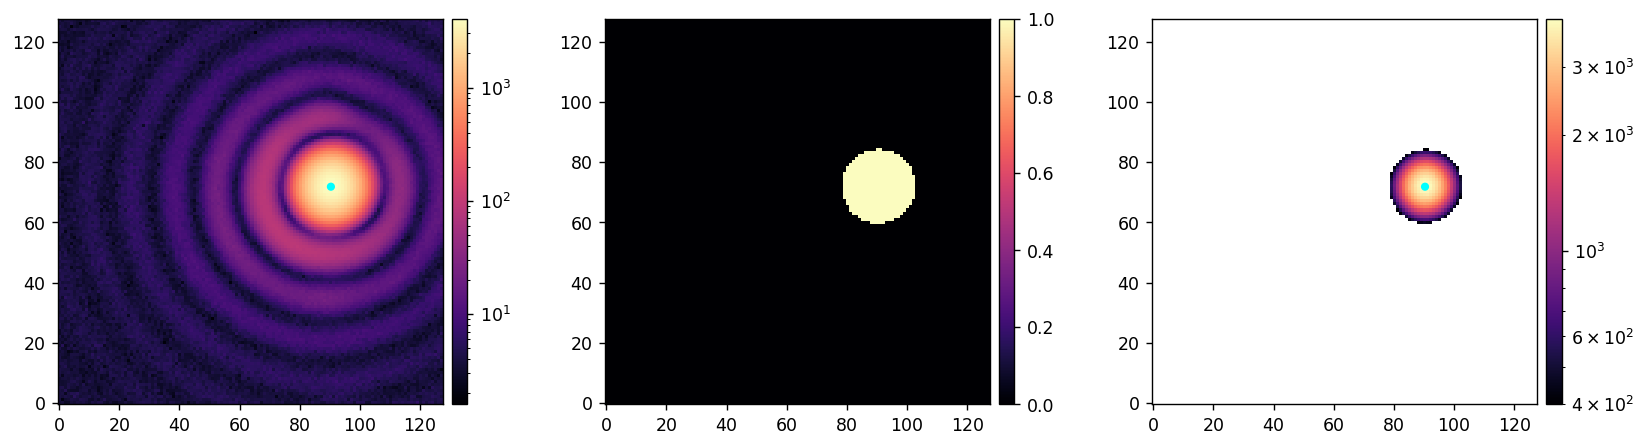

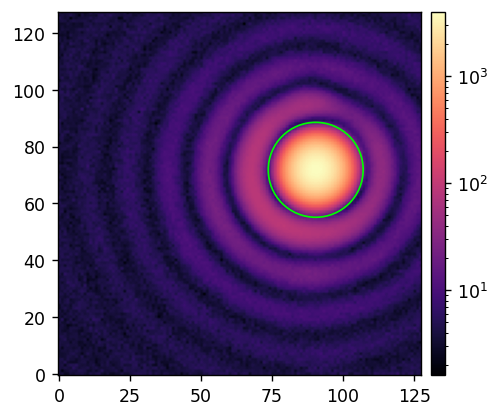

In [27]:
reload(utils)

cam.Nframes = 200
im = cam.snap()

cen = utils.centroid(
    im,
    thresh=0.1*im.max(),
)
utils.imshow(
    [im], 
    norms=[LogNorm()],
    all_patches=[[Circle(cen, 1.22/pxscl_lamD, fill=False, color='lime')]],
)

# initialize the FSM channel.

In [18]:
reload(fsm_utils)
fsm_utils.power_fsm('On', client0)

In [19]:
fsm_stream0 = ImageStream('dm00disp00')
fsm_stream1 = ImageStream('dm00disp01')
fsm_stream1.shape

(1, 3)

In [26]:
fsm_stream0.write(v_bias)

In [8]:
fsm_stream0.write(zero)

In [8]:
fsm_stream1.write(zero)

In [47]:
fsm_stream1.write(np.array([[-1, 1, 1]]).T)

In [32]:
fsm_stream1.write(np.random.randn(3,1))

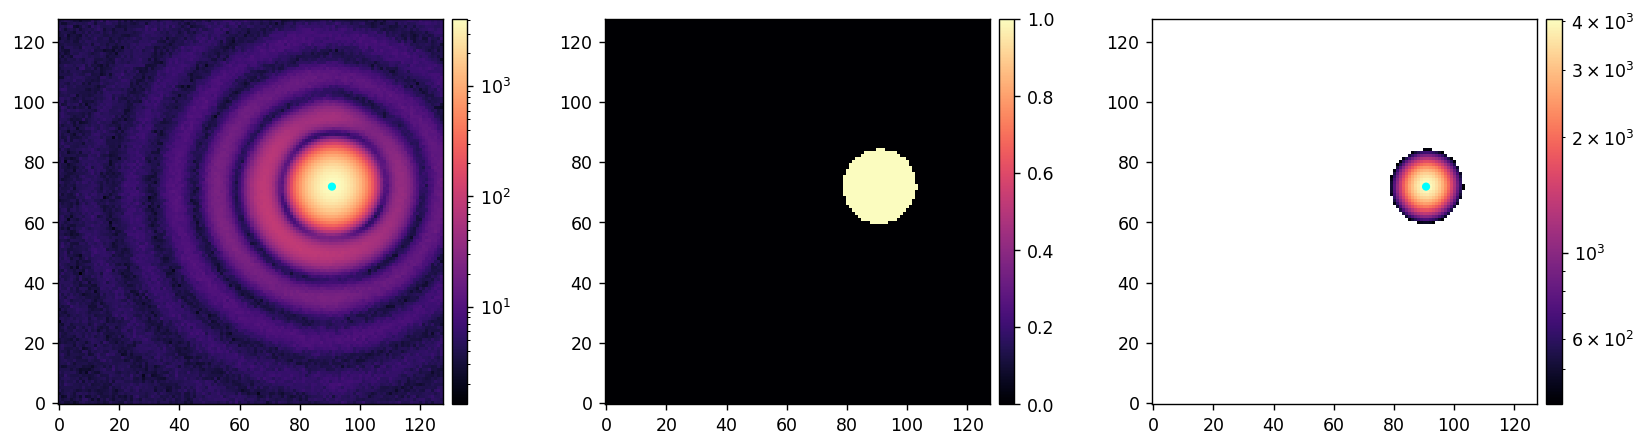

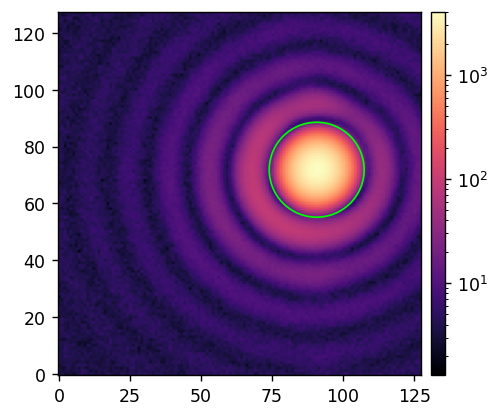

In [ ]:
reload(utils)

cam.Nframes = 200
im = cam.snap()

cen = utils.centroid(
    im,
    thresh=0.1*im.max(),
)
shift = cen - npsf//2
print(cen, shift)
utils.imshow(
    [im], 
    norms=[LogNorm()],
    all_patches=[[Circle(cen, 1.22/pxscl_lamD, fill=False, color='lime')]],
)

In [43]:
# cam.set_roi(948, 625, npsf, client0)
cam.set_roi(948+shift[0], 625+shift[1], npsf, client0)

# Make FSM do a circle

In [44]:
reload(fsm_utils)
amp = 1*as_per_lamD 
amp = 2000*rad_per_lamD 
print(amp)

freq = 1
t_max = 1/freq
Nsamps = 19
Nsamps = 37
Nsamps = 51
Nsamps = 201
# Nsamps = 181
times = np.linspace(0, t_max, Nsamps)

tip_wave = amp*np.sin(2*np.pi*freq*times)/np.sqrt(2)
tilt_wave = amp*np.cos(2*np.pi*freq*times)/np.sqrt(2)
volt_commands = np.zeros((Nsamps, 3, 1))
for i in range(Nsamps):
    volt_commands[i] = fsm_utils.get_fsm_volts(tip=tip_wave[i], tilt=tilt_wave[i])
# volt_commands += v_bias

0.18895522388059702


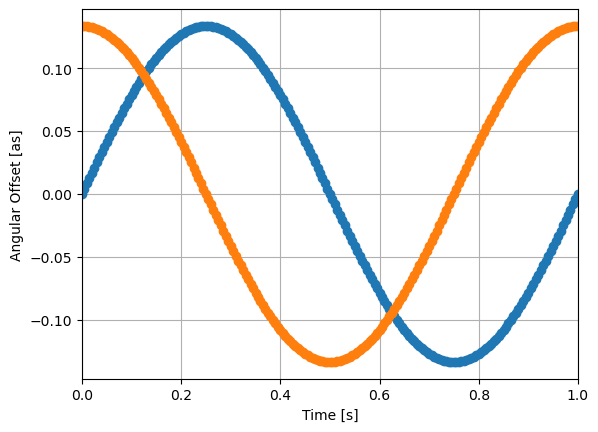

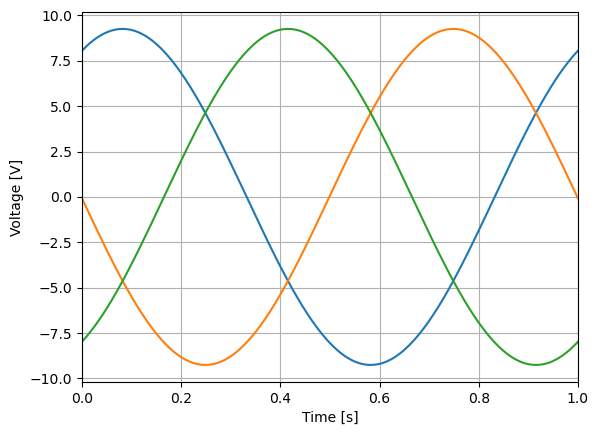

In [45]:
import matplotlib.pyplot as plt
plt.plot(times, tip_wave, marker='o')
plt.plot(times, tilt_wave, marker='o')
plt.xlim([0, t_max])
plt.xlabel('Time [s]')
plt.ylabel('Angular Offset [as]')
plt.grid()
plt.show()

plt.plot(times, volt_commands[:,0])
plt.plot(times, volt_commands[:,1])
plt.plot(times, volt_commands[:,2])
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.xlim([0, t_max])
plt.grid()
plt.show()

In [56]:
fsm_stream1.write(volt_commands[0]*0)

In [46]:
freq = 1 * Nsamps
try:
    print('Modulating FSM ...')
    i = 0
    while i<Nsamps+1:
        if i==Nsamps-1:
            i = 0
        fsm_stream1.write(volt_commands[i])
        time.sleep(1/freq)
        # time.sleep(3)
        i += 1
        # print(i)
except KeyboardInterrupt:
    print('FSM modulation stopped!')
    fsm_stream1.write(zero)
    fsm_stream0.write(v_bias)

Modulating FSM ...
FSM modulation stopped!


In [47]:
fsm_stream0.write(zero)
fsm_stream1.write(zero)

In [48]:
fsm_utils.power_fsm('Off', client0)